### Fine Tune Parakeet


In [1]:
# !uv pip install \
#   torch==2.6.0 \
#   torchvision==0.21.0 \
#   --index-url https://download.pytorch.org/whl/cu121 \
#   --system

!uv pip install \
  "nemo_toolkit[asr]" \
  "omegaconf>=2.3.0" \
  "pandas>=2.2.0" \
"lightning"\
  --system

Using Python 3.12.6 environment at: /usr/local
Resolved 190 packages in 2.18s
⠙ Preparing packages... (0/84)
⠙ Preparing packages... (0/84)
⠙ Preparing packages... (0/84)
ruamel-yaml ------------------------------     0 B/115.33 KiB
⠙ Preparing packages... (0/84)
ruamel-yaml ------------------------------ 14.83 KiB/115.33 KiB
⠙ Preparing packages... (0/84)
mako       ------------------------------     0 B/76.66 KiB
ruamel-yaml ------------------------------ 14.83 KiB/115.33 KiB
⠙ Preparing packages... (0/84)
mako       ------------------------------ 14.81 KiB/76.66 KiB
ruamel-yaml ------------------------------ 14.83 KiB/115.33 KiB
⠙ Preparing packages... (0/84)
text-unidecode ------------------------------     0 B/76.32 KiB
mako       ------------------------------ 14.81 KiB/76.66 KiB
ruamel-yaml ------------------------------ 14.83 KiB/115.33 KiB
⠙ Preparing packages... (0/84)
text-unidecode ------------------------------ 14.76 KiB/76.32 KiB
mako       ------------------------------ 

In [2]:
import json
import csv
from pathlib import Path
from urllib.parse import unquote, urlparse

import lightning.pytorch as pl
import torch
from nemo.collections.asr.models import ASRModel
from nemo.utils.exp_manager import exp_manager
from nemo.utils.trainer_utils import resolve_trainer_cfg
from omegaconf import OmegaConf, open_dict

torch.set_float32_matmul_precision("high")


[NeMo W 2026-04-17 09:38:04 nemo_logging:364] /usr/local/lib/python3.12/site-packages/lhotse/recipes/iwslt22_ta.py:323: SyntaxWarning: invalid escape sequence '\s'
      text = re.sub("\s+", " ", text)
    
[NeMo W 2026-04-17 09:38:04 nemo_logging:364] /usr/local/lib/python3.12/site-packages/lhotse/recipes/iwslt22_ta.py:324: SyntaxWarning: invalid escape sequence '\s'
      text = re.sub("\s+\.\s+", ".", text)
    
[NeMo W 2026-04-17 09:38:06 megatron_init:62] Megatron num_microbatches_calculator not found, using Apex version.
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.
[NeMo W 2026-04-17 09:38:09 nemo_logging:364] /usr/local/lib/python3.12/site-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
      m = re.match('([su]([0-9]{1,2})p?) \((

In [2]:

BASE_DIR = Path.cwd() / "data"

TRAIN_CSV = BASE_DIR / "data" / "train.csv"
VAL_CSV = BASE_DIR / "data" / "validation.csv"

TRAIN_AUDIO_DIR = BASE_DIR / "data" / "train"
VAL_AUDIO_DIR = BASE_DIR / "data" / "validate"

MANIFEST_DIR = BASE_DIR / "data" / "manifests"
MODEL_DIR = BASE_DIR / "models"

MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
def clip_filename(url: str, start: float, end: float) -> str:
    """Reproduce the same filename logic as download_clips.py."""
    stem = Path(unquote(urlparse(url).path).split("/")[-1]).stem
    return f"{stem}_{int(start)}_{int(end)}.wav"


def parse_viewer_url(viewer_url: str) -> str:
    """Convert your 'viewer' URL into the actual audio file URL."""
    import re
    from urllib.parse import quote

    AUDIO_BASE = "https://a3s.fi/swift/v1/YCSEP_v2"
    segment_id = unquote(urlparse(viewer_url).path.rstrip("/").split("/")[-1])
    body = re.sub(r"_\d+_\d+$", "", segment_id)
    match = re.search(r"(\d{8}--)", body)
    filename_slug = body[match.start() :]
    date, video_id, title_slug = filename_slug.split("--", 2)
    title = title_slug.replace("-", " ")
    return f"{AUDIO_BASE}/{date}--{video_id}--{quote(title)}.wav"


def build_manifest(csv_path: Path, audio_dir: Path, manifest_path: Path) -> int:
    """Convert a CSV to NeMo manifest JSONL; skip missing/bad clips."""
    written = 0
    skipped = 0

    with csv_path.open(newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    with manifest_path.open("w") as out:
        for row in rows:
            url = parse_viewer_url(row["audio"])
            start = float(row["start_time"])
            end = float(row["end_time"])

            wav_name = clip_filename(url, start, end)
            wav_path = audio_dir / wav_name

            if not wav_path.exists():
                skipped += 1
                continue

            duration = end - start
            if duration <= 0 or duration > 25.0:
                skipped += 1
                continue

            entry = {
                "audio_filepath": str(wav_path),
                "duration": round(duration, 3),
                "text": row["text"],
            }
            out.write(json.dumps(entry) + "\n")
            written += 1

    print(f"Manifest {manifest_path.name}: {written} entries, {skipped} skipped")
    return written


train_manifest = MANIFEST_DIR / "train_manifest.jsonl"
val_manifest = MANIFEST_DIR / "val_manifest.jsonl"

build_manifest(TRAIN_CSV, TRAIN_AUDIO_DIR, train_manifest)
build_manifest(VAL_CSV, VAL_AUDIO_DIR, val_manifest)


Manifest train_manifest.jsonl: 3045 entries, 2 skipped
Manifest val_manifest.jsonl: 734 entries, 1 skipped


734

In [6]:
PRETRAINED_MODEL = "nvidia/parakeet-tdt-0.6b-v2"
DEVICES = 1
PRECISION = "bf16-mixed"
BATCH_SIZE = 64
NUM_WORKERS = 8
MAX_STEPS = 1000
VAL_CHECK_INTERVAL = 47
LR = 0.002

cfg = OmegaConf.create(
    {
        "model": {
            "pretrained_model": PRETRAINED_MODEL,
            "adapter": {
                "adapter_name": "asr_sg_english",
                "adapter_module_name": "encoder",
                "adapter_type": "linear",
                "adapter_state_dict_name": "adapter_weights.pt",
                "linear": {"in_features": 1024},
            },
            "train_ds": {
                "manifest_filepath": str(train_manifest),
                "batch_size": BATCH_SIZE,
                "num_workers": NUM_WORKERS,
                "use_lhotse": False,
                "channel_selector": "average",
            },
            "validation_ds": {
                "manifest_filepath": str(val_manifest),
                "batch_size": BATCH_SIZE,
                "num_workers": NUM_WORKERS,
                "use_lhotse": False,
                "channel_selector": "average",
            },
            "optim": {
                "lr": LR,
                "weight_decay": 0.0,
            },
        },
        "trainer": {
            "devices": DEVICES,
            "precision": PRECISION,
            "strategy": "auto",
            "max_steps": MAX_STEPS,
            "val_check_interval": VAL_CHECK_INTERVAL,
            "enable_progress_bar": True,
        },
        "exp_manager": {
            "exp_dir": str(MODEL_DIR / "parakeet_adapter"),
            "name": "ASR-Adapter",
            "create_checkpoint_callback": True,
            "checkpoint_callback_params": {
                "monitor": "val_wer",
                "mode": "min",
                "save_top_k": 3,
            },
        },
    }
)


In [8]:
trainer = pl.Trainer(**resolve_trainer_cfg(cfg.trainer), logger=False, enable_checkpointing=False)
exp_log_dir = exp_manager(trainer, cfg.get("exp_manager", None))
model_cfg = ASRModel.from_pretrained(PRETRAINED_MODEL, return_config=True)
# Merge our data/optim config into the model config
with open_dict(model_cfg):
    model_cfg.train_ds = OmegaConf.merge(model_cfg.train_ds, cfg.model.train_ds)
    model_cfg.validation_ds = OmegaConf.merge(
        model_cfg.validation_ds, cfg.model.validation_ds
    )
    model_cfg.optim = OmegaConf.merge(model_cfg.optim, cfg.model.optim)
model = ASRModel.from_pretrained(
    PRETRAINED_MODEL,
    override_config_path=model_cfg,
    trainer=trainer,
)
# Disable CUDA graph decoder (incompatible with newer PyTorch)
with open_dict(model.cfg):
    model.cfg.decoding.greedy.use_cuda_graph_decoder = False
model.change_decoding_strategy(model.cfg.decoding)
# Set up data loaders and optimizer
model.setup_training_data(model.cfg.train_ds)
model.setup_multiple_validation_data(model.cfg.validation_ds)
model.setup_optimization(cfg.model.optim)
# Optional: disable spec augmentation
model.spec_augmentation = None

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[NeMo I 2026-04-17 09:39:03 exp_manager:594] ExpManager schema
[NeMo I 2026-04-17 09:39:03 exp_manager:595] {'explicit_log_dir': None, 'exp_dir': None, 'name': None, 'version': None, 'use_datetime_version': True, 'resume_if_exists': False, 'resume_past_end': False, 'resume_ignore_no_checkpoint': False, 'resume_from_checkpoint': None, 'create_tensorboard_logger': True, 'summary_writer_kwargs': None, 'create_wandb_logger': False, 'wandb_logger_kwargs': None, 'create_mlflow_logger': False, 'mlflow_logger_kwargs': {'experiment_name': None, 'run_name': None, 'tracking_uri': None, 'tags': None, 'save_dir': './mlruns', 'prefix': '', 'artifact_location': None, 'run_id': None, 'log_model': False}, 'create_dllogger_logger': False, 'dllogger_logger_kwargs': {'verbose': False, 'stdout': False, 'json_file': './dllogger.json'}, 'create_clearml_logger': False, 'clearml_logger_kwargs': {'project': None, 'task': None, 'connect_pytorch': False, 'model_name': None, 'tags': None, 'log_model': False, 'log_

[NeMo W 2026-04-17 09:39:03 exp_manager:1413] The checkpoint callback was told to monitor a validation value and trainer's max_steps was set to 1000. Please ensure that max_steps will run for at least 1 epochs to ensure that checkpointing will not error out.


[NeMo I 2026-04-17 09:39:03 exp_manager:804] TFLOPs per sec per GPU will be calculated, conditioned on supported models. Defaults to -1 upon failure.


parakeet-tdt-0.6b-v2.nemo:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

[NeMo I 2026-04-17 09:39:22 mixins:184] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


[NeMo W 2026-04-17 09:39:22 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: false
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: /root/data/data/manifests/train_manifest.jsonl
    sample_rate: 16000
    shuffle: true
    num_workers: 8
    pin_memory: true
    max_duration: 40.0
    min_duration: 0.1
    text_field: answer
    batch_duration: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: 30
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    batch_size: 64
    channel_selector: average
    
[NeMo W 2026-04-17 09:39:22 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid c

[NeMo I 2026-04-17 09:39:26 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-04-17 09:39:26 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-04-17 09:39:27 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-04-17 09:39:31 save_restore_connector:285] Model EncDecRNNTBPEModel was successfully restored from /root/.cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v2/snapshots/1b149a3589351c96ddb101709fe7dd9c7069572f/parakeet-tdt-0.6b-v2.nemo.
[NeMo I 2026-04-17 09:39:31 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0

In [9]:
from omegaconf import OmegaConf, open_dict

adapter_cfg = cfg.model.adapter

# Build clean config from scratch with only valid LinearAdapter params
adapter_type_cfg = OmegaConf.create({
    "_target_": "nemo.collections.common.parts.adapter_modules.LinearAdapter",
    "in_features": adapter_cfg.linear.in_features,
    "dim": 64,  # bottleneck dim, adjust as needed
    "activation": "swish",
    "norm_position": "pre",
    "dropout": 0.0,
})

adapter_name = f"joint:{adapter_cfg.adapter_name}"

model.add_adapter(adapter_name, cfg=adapter_type_cfg)
model.set_enabled_adapters(enabled=False)
model.set_enabled_adapters(adapter_name, enabled=True)
model.freeze()
model = model.train()
model.unfreeze_enabled_adapters()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(
    f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)"
)

[NeMo W 2026-04-17 09:39:44 asr_adapter_mixins:221] Module `encoder` exists, but ConformerEncoder does not implement `AdapterModuleMixin`


[NeMo I 2026-04-17 09:39:44 adapter_utils:84] Updating RNNTJoint Adapter input dim from 1024 to 640
[NeMo I 2026-04-17 09:39:44 adapter_mixins:811] Setting adapter 'asr_sg_english' status : Enabled = False
[NeMo I 2026-04-17 09:39:44 adapter_mixins:826] Setting adapter 'joint:asr_sg_english' status : Enabled = True
[NeMo I 2026-04-17 09:39:44 adapter_mixins:466] Froze module encoder.layers.0.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
[NeMo I 2026-04-17 09:39:44 adapter_mixins:466] Froze module encoder.layers.1.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
[NeMo I 2026-04-17 09:39:44 adapter_mixins:466] Froze module encoder.layers.2.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
[NeMo I 2026-04-17 09:39:44 adapter_mixins:466] Froze module encoder.layers.3.conv.batch_norm: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True

In [ ]:
import json
from lightning.pytorch.callbacks import Callback

class MetricsLogger(Callback):
    """Captures train loss and val WER at each logged step."""

    def __init__(self):
        super().__init__()
        self.train_loss = []
        self.val_wer = []

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        loss = trainer.callback_metrics.get("reduced_train_loss")
        if loss is not None:
            self.train_loss.append(
                {"step": trainer.global_step, "loss": float(loss)}
            )

    def on_validation_end(self, trainer, pl_module):
        wer_val = trainer.callback_metrics.get("val_wer")
        if wer_val is not None:
            self.val_wer.append(
                {"step": trainer.global_step, "wer": float(wer_val)}
            )

metrics_logger = MetricsLogger()
trainer.callbacks.append(metrics_logger)

In [11]:
trainer.fit(model)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[NeMo I 2026-04-17 09:41:17 modelPT:830] Optimizer config = Adam (
    Parameter Group 0
        amsgrad: False
        betas: (0.9, 0.999)
        capturable: False
        decoupled_weight_decay: False
        differentiable: False
        eps: 1e-08
        foreach: None
        fused: None
        lr: 0.002
        maximize: False
        weight_decay: 0.0
    )
[NeMo I 2026-04-17 09:41:17 lr_scheduler:844] Scheduler not initialized as no `sched` config supplied to setup_optimizer()



  | Name         | Type                              | Params | Mode 
---------------------------------------------------------------------------
0 | preprocessor | AudioToMelSpectrogramPreprocessor | 0      | train
1 | encoder      | ConformerEncoder                  | 608 M  | train
2 | decoder      | RNNTDecoder                       | 7.2 M  | train
3 | joint        | RNNTJoint                         | 1.8 M  | train
4 | loss         | RNNTLoss                          | 0      | train
5 | wer          | WER                               | 0      | train
---------------------------------------------------------------------------
83.2 K    Trainable params
617 M     Non-trainable params
617 M     Total params
2,471.637 Total estimated model params size (MB)
687       Modules in train mode
24        Modules in eval mode


Sanity Checking: |                                                                       | 0/? [00:00<?, ?it/s…

[NeMo I 2026-04-17 09:42:17 wer:336] 
    
[NeMo I 2026-04-17 09:42:17 wer:337] WER reference:Ethan
[NeMo I 2026-04-17 09:42:17 wer:338] WER predicted:Mm-hmm.
[NeMo I 2026-04-17 09:42:17 wer:336] 
    
[NeMo I 2026-04-17 09:42:17 wer:337] WER reference:sort of bookmark our day, our year with, oh, I went to this holiday, I went to that holiday. It just feels like a constant kind of grind. And if you don't try and appreciate the ups and downs a little bit, you'll just feel like you're just coasting through
[NeMo I 2026-04-17 09:42:17 wer:338] WER predicted:of bookmark our our day, our our our year with oh, I went to this holiday, I went to that holiday. It just feels like a constant kind of grind. Yeah. And if you don't try and appreciate the ups and downs a little bit, it'll just feel like you're just coasting through.
[NeMo I 2026-04-17 09:42:17 wer:336] 
    
[NeMo I 2026-04-17 09:42:17 wer:337] WER reference:You have Taiwan, which is very open in some way, but not if you're from main

...

[NeMo I 2026-04-17 12:06:07 wer:336] 
    
[NeMo I 2026-04-17 12:06:07 wer:337] WER reference:Ethan
[NeMo I 2026-04-17 12:06:07 wer:338] WER predicted:
[NeMo I 2026-04-17 12:06:07 wer:336] 
    
[NeMo I 2026-04-17 12:06:07 wer:337] WER reference:sort of bookmark our day, our year with, oh, I went to this holiday, I went to that holiday. It just feels like a constant kind of grind. And if you don't try and appreciate the ups and downs a little bit, you'll just feel like you're just coasting through
[NeMo I 2026-04-17 12:06:07 wer:338] WER predicted:sort of bookmark our day our year with oh, I went to this holiday, I went to that holiday. it just feels like a constant kind of grind. Yeah. And if you don't try and appreciate the ups and downs a little bit, it'll just feel like you're just coasting through
[NeMo I 2026-04-17 12:06:07 wer:336] 
    
[NeMo I 2026-04-17 12:06:07 wer:337] WER reference:You have Taiwan, which is very open in some way, but not if you're from mainland China, very

Epoch 20, global step 987: 'val_wer' was not in top 3


[NeMo I 2026-04-17 12:07:24 nemo_model_checkpoint:573] Checkpoint save for step 987 started at 1776427644.2544034.
[NeMo I 2026-04-17 12:09:02 wer:336] 
    
[NeMo I 2026-04-17 12:09:02 wer:337] WER reference:they are taking... I
[NeMo I 2026-04-17 12:09:02 wer:338] WER predicted:they they are taking
[NeMo I 2026-04-17 12:09:02 wer:336] 
    
[NeMo I 2026-04-17 12:09:02 wer:337] WER reference:because you're quarreling about money, okay, I'll go and find a job.
[NeMo I 2026-04-17 12:09:02 wer:338] WER predicted:Yeah. Then because you're quarreling about money, okay, I'm going to find a job.
[NeMo I 2026-04-17 12:09:03 wer:336] 
    
[NeMo I 2026-04-17 12:09:03 wer:337] WER reference:he still even, you know, he put that out there for people to, you know, judge and all.
[NeMo I 2026-04-17 12:09:03 wer:338] WER predicted:he's still even, you know, he put that out there for people to, you know, judge, you know?
[NeMo I 2026-04-17 12:09:03 wer:336] 
    
[NeMo I 2026-04-17 12:09:03 wer:337] 

`Trainer.fit` stopped: `max_steps=1000` reached.


[NeMo I 2026-04-17 12:09:05 nemo_model_checkpoint:573] Checkpoint save for step 1000 started at 1776427745.898915.


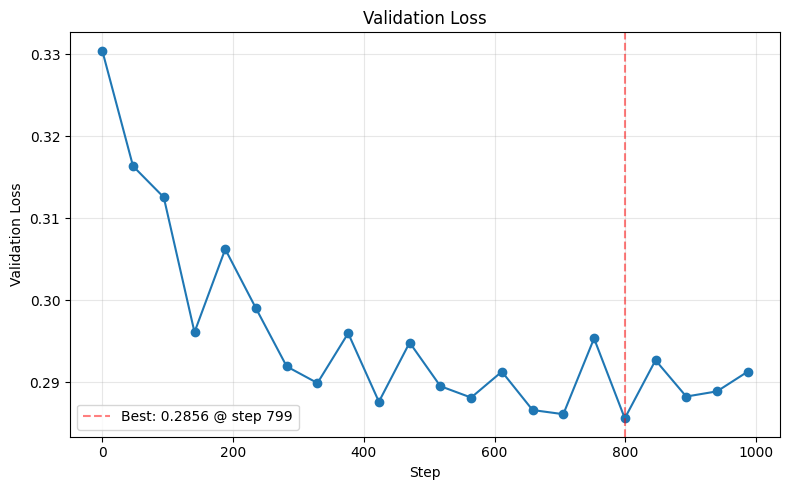

In [5]:
import json
import matplotlib.pyplot as plt

metrics_path = MODEL_DIR / "training_metrics.json"
with metrics_path.open() as f:
    metrics = json.load(f)

val_loss = metrics["val_wer"]
steps = [m["step"] for m in val_loss]
losses = [m["wer"] for m in val_loss]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, losses, marker="o", linewidth=1.5)
best_idx = losses.index(min(losses))
ax.axvline(steps[best_idx], color="r", linestyle="--", alpha=0.5,
           label=f"Best: {losses[best_idx]:.4f} @ step {steps[best_idx]}")
ax.set_xlabel("Step")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / "val_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
ckpt_dir = exp_log_dir / "checkpoints"
adapter_save_path = ckpt_dir / adapter_cfg.adapter_state_dict_name
model.save_adapters(str(adapter_save_path))
print(f"Adapter weights saved to: {adapter_save_path}")

# Also report the best .nemo checkpoint for later inference
nemo_ckpts = sorted(ckpt_dir.glob("*.nemo"))
if nemo_ckpts:
    print(f"Best checkpoint: {nemo_ckpts[-1]}")


Adapter weights saved to: /root/data/models/parakeet_adapter/ASR-Adapter/2026-04-17_09-39-03/checkpoints/adapter_weights.pt
Best checkpoint: /root/data/models/parakeet_adapter/ASR-Adapter/2026-04-17_09-39-03/checkpoints/ASR-Adapter.nemo


In [14]:
!uv pip install huggingface_hub --system

Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 33ms


In [ ]:
import os
from pathlib import Path
from huggingface_hub import HfApi

HF_TOKEN = os.environ["HF_TOKEN"]
HF_REPO = "joentze/parakeet-tdt-sg-english"  # <-- change this

CKPT_DIR = Path("/root/data/models/parakeet_adapter/ASR-Adapter/2026-04-15_09-20-57/checkpoints")
ADAPTER_PATH = CKPT_DIR / "adapter_weights.pt"
NEMO_PATH = CKPT_DIR / "parakeet-tdt-ycsep.nemo"

api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=HF_REPO, repo_type="model", exist_ok=True)

# Adapter only (~few MB)
api.upload_file(
    path_or_fileobj=str(ADAPTER_PATH),
    path_in_repo="adapter_weights.pt",
    repo_id=HF_REPO,
)

# Full .nemo checkpoint (~2.3 GiB) — standalone model
api.upload_file(
    path_or_fileobj=str(NEMO_PATH),
    path_in_repo="ASR-Adapter.nemo",
    repo_id=HF_REPO,
)

print(f"Uploaded to: https://huggingface.co/{HF_REPO}")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...0-57/checkpoints/adapter_weights.pt: 100%|##########|  577kB /  577kB            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...checkpoints/parakeet-tdt-ycsep.nemo:   1%|          | 16.7MB / 2.47GB            

Uploaded to: https://huggingface.co/joentze/parakeet-tdt-sg-english
